In [1]:
# import necessary modules
# uncomment to get plots displayed in notebook
%matplotlib inline

### import class wrapper

from classy import Class

### math stuff
import numpy as np

### plotting stuff
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.interpolate import interp1d

import tqdm as tqdm


In [2]:
### Plot helpers

plt.rcParams.update({
    "text.usetex": True,                      # Use LaTeX to render all text
    "text.latex.preamble": r"\usepackage{amsmath}", # Load amsmath for advanced math typography
    "font.family": "serif",                   # Use a serif font for the main text
    "font.serif": ["Computer Modern Roman"],  # Match standard LaTeX default font
    "font.size": 12,                          # Standard font size for scientific papers
    "axes.labelsize": 12,                     # Size of the x and y axis labels
    "xtick.labelsize": 10,                     # Size of the x-tick labels
    "ytick.labelsize": 10,                     # Size of the y-tick labels
    "legend.fontsize": 10,                     # Size of the legend text
    "figure.titlesize": 14                    # Size of the figure's main title
})

# colorblind-friendly palette
colors_colorblind = ['#377eb8', '#ff7f00', '#4daf4a',
          '#f781bf', '#a65628', '#984ea3',
          '#999999', '#e41a1c', '#dede00']

In [3]:
### RUN LCDM for comparison first
lcdm = Class()
lcdm.set({ 'h': 0.67810,
          'omega_cdm': 0.1201075,
          # add neutrinos to make it more realistic
          'N_ncdm': 1,
          'deg_ncdm': 3, # 3 neutrino species
          'm_ncdm': 0.02, # in eV, set a small mass for the neutrino to avoid issues with the early universe
          'T_ncdm': 0.71611, # T_ncdm/T_cmb, set to the standard value for neutrinos
          'N_ur': 0.00441, # no massless neutrinos
          })
lcdm.compute()

### Read background quantities for LCDM

bg_lcdm = lcdm.get_background()
z_lcdm = bg_lcdm['z']
a_lcdm = 1/(1+z_lcdm)
rho_cdm_lcdm = bg_lcdm['(.)rho_cdm']
rho_g_lcdm = bg_lcdm['(.)rho_g']
rho_nu_lcdm = bg_lcdm['(.)rho_ncdm[0]']
H_lcdm = bg_lcdm['H [1/Mpc]']
rho_tot_lcdm = bg_lcdm['(.)rho_tot']
z_eq_lcdm = lcdm.get_current_derived_parameters(['z_eq'])
print(f"Redshift of matter-radiation equality in LCDM: {z_eq_lcdm['z_eq']:.2f}")


Redshift of matter-radiation equality in LCDM: 3405.75


In [4]:
### Constants

num_of_gigayears = 0.1
tau_acc = num_of_gigayears*3600*24*365*1e9 # convert to seconds
f_acc = 0.1 # rho_acc/rho_cdm today
m_dcdm = 1e16
m_wdm = 1e16 # in accDM model it should be the same as mass of the DM particle before acceleration, but this implementation is more general and allows to set them independently
omega_dm = 0.1201075
kappa = 12
a_t = 0.13

In [ ]:
### Run CLASS ###
AccCLASS = {}
# Initialize dictionaries for background and perturbation quantities
bgAcc = {}
z, a, H = {}, {}, {}
rho_g, rho_cdm, rho_dcdm, rho_b, rho_ur, rho_lambda = {}, {}, {}, {}, {}, {}
rho_acc, p_acc, w_acc = {}, {}, {}
rho_nu = {}
rho_tot, rho_crit = {}, {}
z_eq = {}

eta_list = [1e-2, 1e-1, 1, 10]

for eta in tqdm.tqdm(eta_list):
    print(f'Running CLASS for eta = {eta}') 
    AccCLASS = Class()
    AccCLASS.set({
                    ### LCDM params
                    'h': 0.67810,
                    'omega_cdm': omega_dm*(1-f_acc),     # Set the CDM density
                    ### accDM params
                    'vary_Gamma_wdm': 1,                 # Don't vary the decay constant of DCDM, we will set it to a fixed value below
                    'kappa_mon': kappa,                       # 
                    'a_t_mon': a_t,                       # Scale factor at which the acceleration happens
                    'f_wdm': f_acc/(1-f_acc),             # Set the fraction of all DM that can be accelerated, i.e. f_acc = rho_acc/(rho_c+rho_acc) in far past. It's a bit weird to set it like this, but eh
                    #'omega_ini_dcdm': omega_dm*f_acc,    # Set the density of the WDM component
                    'eta_wdm': eta,                      # Energy gain of the WDM component defined via the enrgy right after acceleration E_wdm = m_wdm(1+\eta)
                    "tau_wdm": tau_acc,                  # "Lifetime" of the DCDM component, set to a large value to ensure that the acceleration happens late enough
                    "m_wdm_in_GeV": m_wdm,               # accDM mass in GeV
                    "m_cdm_in_GeV": m_dcdm,              # DCDM mass in GeV, in accDM case these two masses should be the same, but this implementation is more general
                    "N_ncdm": 2,                         # accDM is always the last ncdm species, so it has index N_ncdm-1, here we sset N_ncdm=2 to have both massive neutrinos and accDM in the ncdm sector
                    "deg_ncdm": "3,1",                   # 3 neutrino species and 1 degrees of freedom for the WDM component 
                    "m_ncdm": f"0.02, {m_wdm*1e9}",      # Set a small mass for the neutrino species and a large mass for the WDM component (in eV), the 2nd entry shuld be irrelevant as m_ncdm[1] should be overwritten in the code by m_wdm_in_GeV
                    "T_ncdm": "0.71611, 1",              # Set the same temperature for the WDM component as for the neutrinos, CHECK DEPENDENCE OF THE RESULTS ON THE 2nd ENTRY
                    "ncdm_N_momentum_bins" : "15, 5001", # Set a higher number of momentum bins for the WDM component, maybe the same number as evolution steps? But that's 40000, so a lot. FOR SIMPSION THE NUBMER OF MOMENTUM BINS SHOULD BE ODD, CHECK THIS
                    "N_ur": 0.00441,                     # Set the number of massless neutrino species to 0 since we are including them as ncdm species
                    "ncdm_quadrature_strategy": "0, 4",  # Quadrature strategy for each ncdm species, 0 (CLASS auto quadrature) for neutrinos, 4 for WDM (logarithmic Simpson, added in CLASS by me based on 2102.12498 -- the repo linked in this paper has WRONG IMPLEMENTATION!)
                    })
    AccCLASS.compute()
    bgAcc[eta] = AccCLASS.get_background()
    
    # Extract some background cosmological quantities
    H[eta] = bgAcc[eta]['H [1/Mpc]']
    z[eta] = bgAcc[eta]['z']
    a[eta] = 1/(1+z[eta])
    #print(len(z[eta]))

    # Extract the usual energy densities
    rho_g[eta] = bgAcc[eta]['(.)rho_g']
    rho_b[eta] = bgAcc[eta]['(.)rho_b']
    rho_cdm[eta] = bgAcc[eta]['(.)rho_cdm']
    
    # Extract energy densities of the DCDM and WDM components and the pressure of the WDM component
    rho_dcdm[eta] = bgAcc[eta]['(.)rho_dcdm']
    rho_nu[eta] = bgAcc[eta]['(.)rho_ncdm[0]']
    rho_acc[eta] = bgAcc[eta]['(.)rho_ncdm[1]']
    p_acc[eta] = bgAcc[eta]['(.)p_ncdm[1]']
    
    w_acc[eta] = p_acc[eta]/rho_acc[eta]
        
    rho_lambda[eta] = bgAcc[eta]['(.)rho_lambda']
    rho_ur[eta] = bgAcc[eta]['(.)rho_ur']
    rho_tot[eta] = bgAcc[eta]['(.)rho_tot']
    rho_crit[eta] = bgAcc[eta]['(.)rho_crit']
    
    z_eq[eta] = AccCLASS.get_current_derived_parameters(['z_eq'])
        

  0%|          | 0/4 [00:00<?, ?it/s]

Running CLASS for eta = 0.01


 25%|██▌       | 1/4 [00:03<00:09,  3.26s/it]

Running CLASS for eta = 0.1


 50%|█████     | 2/4 [00:06<00:06,  3.25s/it]

Running CLASS for eta = 1


 75%|███████▌  | 3/4 [00:09<00:03,  3.29s/it]

Running CLASS for eta = 10


100%|██████████| 4/4 [00:13<00:00,  3.35s/it]


Plotting for eta = 0.01
3353.9109063611504
Plotting for eta = 0.1
3353.9109063611504
Plotting for eta = 1
3353.9109063611504
Plotting for eta = 10
3353.9109063611504


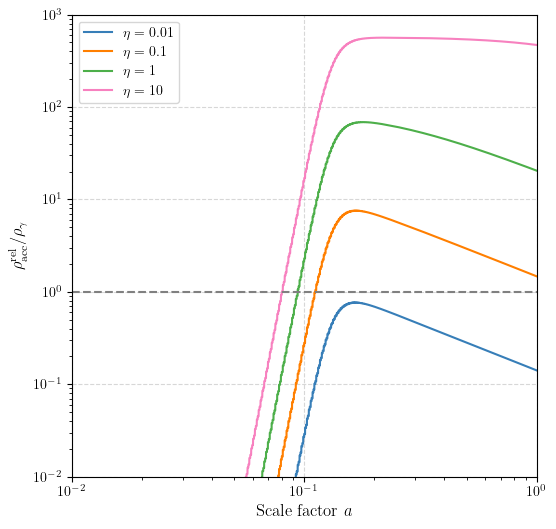

In [6]:
from scipy.ndimage import gaussian_filter1d

### Plot evolution of rho_adm for different values of f_mon
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

rho_cdm_lcdm_interp = interp1d(z_lcdm, rho_cdm_lcdm, kind='linear', bounds_error=False, fill_value='extrapolate')

### Smmothen rho_acc to avoid wiggles in the plot
smooth_rho_acc = {}
smooth_p_acc = {}
for eta in eta_list:
    smooth_rho_acc[eta] = gaussian_filter1d(rho_acc[eta], sigma=20) # Gaussian filter with a standard deviation of 20
    smooth_p_acc[eta] = gaussian_filter1d(p_acc[eta], sigma=20) # Gaussian filter with a standard deviation of 20

for eta in eta_list:
    print(f'Plotting for eta = {eta}')
    a_acc = a[eta]
    
    ax.plot(a_acc, 3*p_acc[eta]/rho_g[eta], label=r'$\eta = {}$'.format(eta), ls = '-', color=colors_colorblind[eta_list.index(eta)])
    
    ax.set_ylabel(r'$\rho_\mathrm{acc}^\mathrm{rel}/\rho_\gamma$')
    ax.set_xlabel(r'Scale factor $a$')
    print(z_eq[eta]['z_eq'])

ax.axhline(1, color='grey', linestyle='--')

ax.legend()
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylim(1e-2, 1000)
ax.set_xlim(1e-2, 1)
ax.grid(ls = '--', alpha = 0.5)
# ax.axvline(1+6, color='grey', linestyle='--', label=r'$z_{\mathrm{acc}}$')


Plotting for eta = 0.01
3353.9109063611504
Plotting for eta = 0.1
3353.9109063611504
Plotting for eta = 1
3353.9109063611504
Plotting for eta = 10
3353.9109063611504


/tmp/ipykernel_19893/1044710282.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


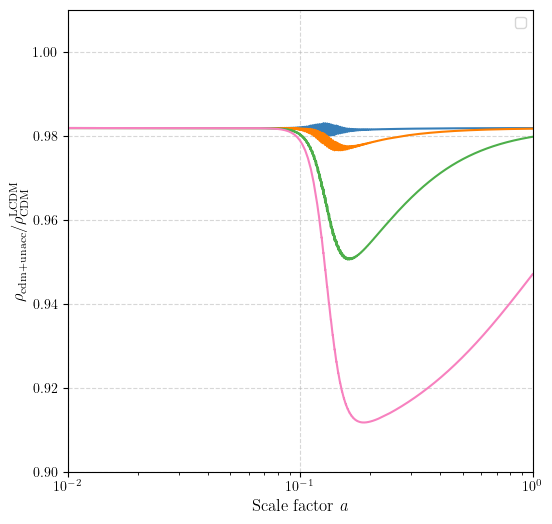

In [7]:
### Plot evolution of rho_adm for different values of f_mon
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

rho_cdm_lcdm_interp = interp1d(a_lcdm, rho_cdm_lcdm, kind='linear', bounds_error=False, fill_value='extrapolate')

for eta in eta_list:
    print(f'Plotting for eta = {eta}')
    a_acc = a[eta]
    
    cold_rho_acc = rho_acc[eta]-3*p_acc[eta]
    
    ax.plot(a_acc, (rho_dcdm[eta]+rho_cdm[eta]+cold_rho_acc)/rho_cdm_lcdm_interp(a_acc), ls = '-', color=colors_colorblind[eta_list.index(eta)])
    
    ax.set_ylabel(r'$\rho_\mathrm{cdm+unacc}/\rho_\mathrm{CDM}^{\mathrm{LCDM}}$')
    ax.set_xlabel(r'Scale factor $a$')
    print(z_eq[eta]['z_eq'])

ax.legend()
ax.set_yscale('linear')
ax.set_xscale('log')
ax.set_ylim(0.9, 1.01)
ax.set_xlim(1e-2, 1)
ax.grid(ls = '--', alpha = 0.5)
# ax.axvline(1+6, color='grey', linestyle='--', label=r'$z_{\mathrm{acc}}$')


Omega_dm (without acc) today for eta = 0.01: 0.2351
Omega_dm (with acc) today for eta = 0.01: 0.2565
Omega_dm (without acc) today for eta = 0.1: 0.2351
Omega_dm (with acc) today for eta = 0.1: 0.2565
Omega_dm (without acc) today for eta = 1: 0.2351
Omega_dm (with acc) today for eta = 1: 0.2570
Omega_dm (without acc) today for eta = 10: 0.2351
Omega_dm (with acc) today for eta = 10: 0.2727


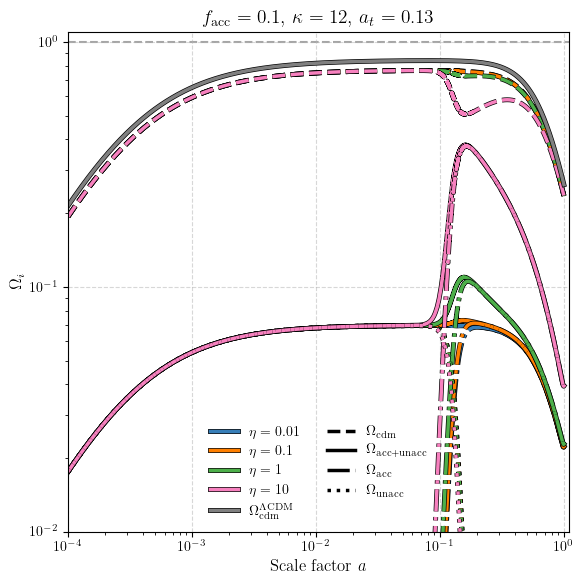

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

outline = [pe.withStroke(linewidth=3.5, foreground='black')]
line_w = 2.5

for idx, eta in enumerate(eta_list):
    a_acc = a[eta]
    c = colors_colorblind[idx % len(colors_colorblind)] # Safe indexing in case eta_list > colors
    
    # cdm = solid (-), acc = dotted (:), dcdm = dashed (--)
    ax.plot(a_acc, rho_cdm[eta]/rho_tot[eta], 
              linewidth=line_w, ls='--', path_effects=outline, color=c)
    ax.plot(a_acc, (rho_dcdm[eta]+smooth_rho_acc[eta])/rho_tot[eta], 
              linewidth=line_w, ls='-', path_effects=outline, color=c, label=rf'$\eta = {eta}$')
    ax.plot(a_acc, smooth_rho_acc[eta]/rho_tot[eta], 
              linewidth=line_w, ls='-.', path_effects=outline, color=c)
    ax.plot(a_acc, rho_dcdm[eta]/rho_tot[eta], 
              linewidth=line_w, ls=':', path_effects=outline, color=c)
    
    #print(rho_dcdm[eta]/(rho_cdm[eta]+rho_dcdm[eta]))
    omega_dm = rho_cdm[eta]/rho_tot[eta] + rho_dcdm[eta]/rho_tot[eta]
    omega_dm_acc = omega_dm + rho_acc[eta]/rho_tot[eta]
    print(f"Omega_dm (without acc) today for eta = {eta}: {omega_dm[-1]:.4f}")
    print(f"Omega_dm (with acc) today for eta = {eta}: {omega_dm_acc[-1]:.4f}")

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_ylabel(r'$\Omega_i$', fontsize=12)
ax.set_xlabel(r'Scale factor $a$', fontsize=12)

ax.set_ylim(1e-2, 1.1)
ax.set_xlim(1e-4, 1.1)

ax.axhline(1, color='grey', linestyle='--', zorder=0, alpha=0.7)

# Lambda CDM Reference Plot
ax.plot(a_lcdm, rho_cdm_lcdm/rho_tot_lcdm, label=r'$\Omega_{\mathrm{cdm}}^{\Lambda\mathrm{CDM}}$', 
          linewidth=line_w, ls='-', path_effects=outline, color='grey')

handles, labels = ax.get_legend_handles_labels()

style_handles = [
    Line2D([0], [0], color='black', lw=line_w, ls='--', label=r'$\Omega_{\mathrm{cdm}}$'),
    Line2D([0], [0], color='black', lw=line_w, ls='-', label=r'$\Omega_{\mathrm{acc}+\mathrm{unacc}}$'),
    Line2D([0], [0], color='black', lw=line_w, ls='-.', label=r'$\Omega_{\mathrm{acc}}$'),
    Line2D([0], [0], color='black', lw=line_w, ls=':', label=r'$\Omega_{\mathrm{unacc}}$'), 
]

ax.legend(handles=handles + style_handles, loc='best', fontsize=10, frameon=False, ncol=2)

ax.grid(ls='--', alpha=0.5)

ax.set_title(rf'$f_{{\text{{acc}}}} = {f_acc}$, $\kappa = {kappa}$, $a_t = {a_t}$', fontsize=14)

plt.tight_layout() # Ensures labels don't get cut off when saving
plt.show()

w_acc today for eta = 0.01: 0.0001
w_acc today for eta = 0.1: 0.0012
w_acc today for eta = 1: 0.0168
w_acc today for eta = 10: 0.2244


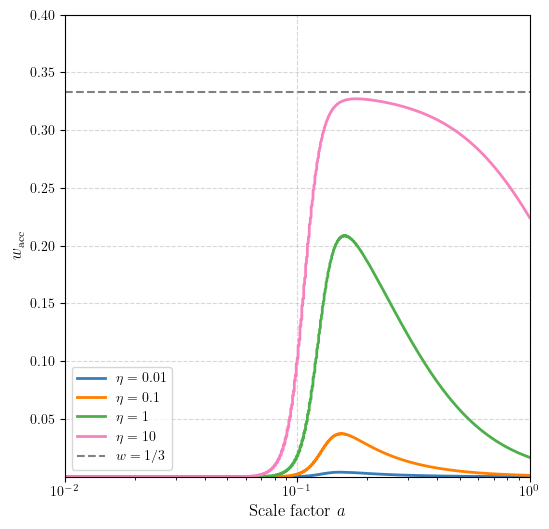

In [9]:
### Plot evolution of rho_adm for different values of f_mon
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

colors = colors_colorblind

for eta in eta_list:
    a_acc = a[eta]
    
    w_acc = p_acc[eta]/(rho_acc[eta]+rho_dcdm[eta])
    print(f"w_acc today for eta = {eta}: {w_acc[-1]:.4f}")
    
    ax.semilogx(a_acc, w_acc, label=r'$\eta = {}$'.format(eta), linewidth=2, ls = '-', color = colors_colorblind[eta_list.index(eta)])

    ax.set_ylabel(r'$w_\mathrm{acc}$')
    ax.set_xlabel(r'Scale factor $a$')
    

# ax.axhline(1, color='grey', linestyle='--')
ax.axhline(1/3, color='grey', linestyle='--', label=r'$w=1/3$', zorder=-1)

ax.legend()
ax.set_yscale('linear')
ax.set_ylim(1e-4, 0.4)
ax.set_xlim(1e-2, 1)
ax.grid(ls = '--', alpha = 0.5)


Ratio at z=0:  1.0
Ratio at z=0:  1.0000000000000002
Ratio at z=0:  1.0
Ratio at z=0:  1.0


/tmp/ipykernel_19893/3388832591.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=14, loc='upper right', frameon=False)


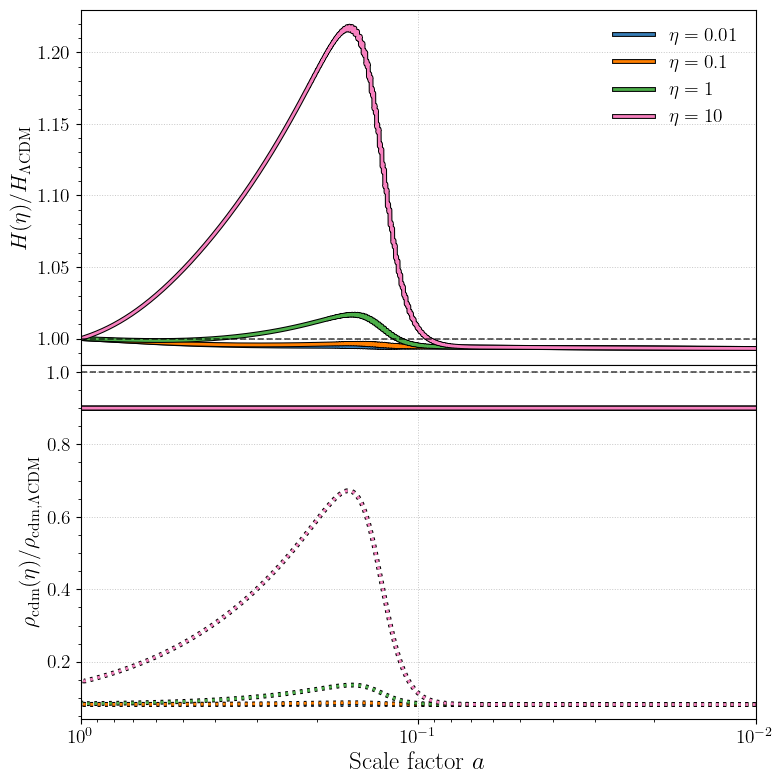

In [10]:
# Set up figure
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# Interpolation functions
interp_H_lcdm = interp1d(a_lcdm, H_lcdm, kind='linear', bounds_error=False, fill_value='extrapolate')
interp_rho_cdm_lcdm = interp1d(a_lcdm, rho_cdm_lcdm, kind='linear', bounds_error=False, fill_value='extrapolate')

colors = colors_colorblind

# Loop over f_mon values
for i, eta in enumerate(eta_list):
    z_mon = z[eta]
    a_mon = a[eta]
    H_mon = H[eta]
    rho_cdm_mon = rho_cdm[eta]
    rho_acc_mon = smooth_rho_acc[eta]
    rho_dcdm_mon = rho_dcdm[eta]


    # Interpolated LCDM quantities onto a[f_mon] grid
    H_lcdm_interp = interp_H_lcdm(a_mon)
    rho_cdm_lcdm_interp = interp_rho_cdm_lcdm(a_mon)

    color = colors[i]
    
    # Plot 1: H[z_tr] / H_lcdm
    H_line = axs[0].semilogx(a_mon, H_mon / H_lcdm_interp, 
                             linewidth=2, path_effects=[pe.withStroke(linewidth=3.5, foreground='black')], 
                             label=rf'$\eta={eta}$', color=color
                    )

    print('Ratio at z=0: ', H_mon[-1]/H_lcdm_interp[-1])
    axs[0].axvline(x=1+z_eq[eta]['z_eq'], linestyle='--', linewidth=1.2, alpha=0.7, color=color)  # z_eq
    # Plot 2: rho_cdm[f_mon] / rho_cdm_lcdm
    rho_line = axs[1].semilogx(a_mon, rho_cdm_mon / (rho_cdm_lcdm_interp), linewidth=2, path_effects=[pe.withStroke(linewidth=3.5, foreground='black')], color=color)
    rho_line_2 = axs[1].semilogx(a_mon, (rho_dcdm_mon+rho_acc_mon)  / (rho_cdm_lcdm_interp), linewidth=2, path_effects=[pe.withStroke(linewidth=3.5, foreground='black')], color=color, ls = ':')

    axs[1].set_ylim(None, 1.02)
    axs[1].axvline(x=1+z_eq[eta]['z_eq'], linestyle='--', linewidth=1.2, alpha=0.7, color=color)  # z_eq

    
# Common plot settings
titles = [
    r'$H(\eta)/H_{\Lambda\mathrm{CDM}}$',
    r'$\rho_{\mathrm{cdm}}(\eta)/\rho_{\mathrm{cdm},\Lambda\mathrm{CDM}}$',
    r'$\chi(\eta)/\chi_{\Lambda\mathrm{CDM}}$'
]

for i, ax in enumerate(axs):
    ax.set_ylabel(titles[i], fontsize=16)
    ax.grid(which='major', linestyle=':', linewidth=0.7, alpha=0.7)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.axhline(y=1, color='black', linestyle='--', linewidth=1.2, alpha=0.7)  # reference line at 1 (for ratios)
    ax.axvline(x=6, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)  # z_t_mon line
    # ax.axvline(x=1+3400, color='blue', linestyle='--', linewidth=1.2, alpha=0.7)  # z_eq line
    ax.set_xlim(1, 1e-2)
    if i == 0:
        ax.legend(fontsize=16, loc='upper right', frameon=False)
        # ax.text(1+21, 1.025, r'$z_{t,\mathrm{mon}}=20$', fontsize=14, verticalalignment='bottom', horizontalalignment='left', color='gray', rotation=90)
        # ax.text(1+3410, 1.03, r'$z_{\mathrm{eq}}$', fontsize=14, verticalalignment='bottom', horizontalalignment='right', color='blue', rotation=90)
    ax.legend(fontsize=14, loc='upper right', frameon=False)

# X-axis label only on bottom plot
axs[-1].set_xlabel(r'Scale factor $a$', fontsize=18)

# Layout adjustments
plt.tight_layout()
plt.subplots_adjust(hspace=0.0)

plt.show()

# Save the figure
fig.savefig('monopole_background.pdf', dpi=300, bbox_inches='tight')

Note that in our case $\rho_{crit}=\rho_{tot}$ as we consider flat FRW $K=0$ and for each $\eta$ it's identical as we force it that way by setting the same $h$.


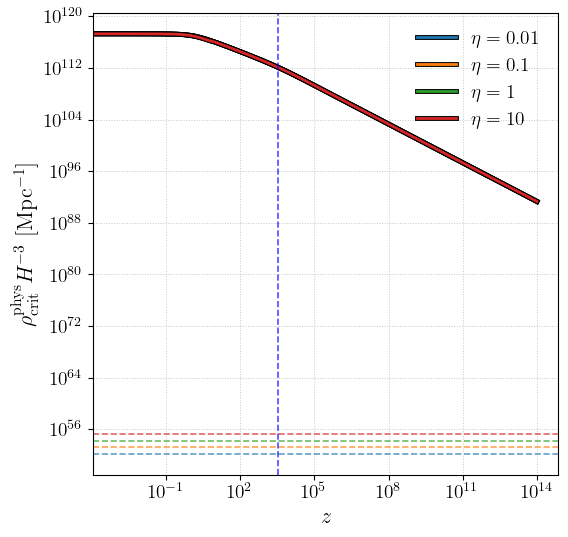

In [11]:
### Plot rho_crit*H^(-3)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

GeV_in_Mpc = 1.56374e38 # GeV in Mpc^-1
CLASS_to_phys = 4.35093e113 # 3/(8*pi*G) in Mpc^-2, conversion factor to go from CLASS units to physical units for energy densities

for eta in eta_list:
    z_mon = z[eta]
    H_mon = H[eta]  # in Mpc^-1
    rho_crit_acc = rho_crit[eta] # in Mpc^-2
    rho_crit_physical = rho_crit_acc * CLASS_to_phys # in Mpc^-4

    ax.loglog(z_mon, rho_crit_physical * H_mon**(-3), label=rf'$\eta={eta}$', linewidth=2, path_effects=[pe.withStroke(linewidth=3.5, foreground='black')], color='C{}'.format(eta_list.index(eta)))
    ax.axhline(y=eta*m_wdm*GeV_in_Mpc, color='C{}'.format(eta_list.index(eta)), linestyle='--', linewidth=1.2, alpha=0.7)
    
ax.set_xlabel(r'$z$', fontsize=16)
ax.set_ylabel(r'$\rho_{\mathrm{crit}}^\mathrm{phys}H^{-3}$ [Mpc$^{-1}$]', fontsize=16)
ax.grid(which='major', linestyle=':', linewidth=0.7, alpha=0.7)
ax.minorticks_on()
ax.tick_params(axis='both', which='major', labelsize=14)
# ax.axvline(x=6, color='gray', linestyle='--', linewidth=1.2, alpha=0.7) 
ax.axvline(x=1+3400, color='blue', linestyle='--', linewidth=1.2, alpha=0.7)  # z_eq line
# ax.set_xlim(0.1, 2e5)
# ax.set_ylim
ax.legend(fontsize=14, loc='upper right', frameon=False)

So it seems that all $\eta$ are allowed and we'd need to go to some extremaly large value to break it. But I may be misunderstanding this. 